1. DAĻA - datu importēšana, tīrīšana un sagatavošana priekš splitting.

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

# Load your 5 datasets
df1 = pd.read_csv('air_void.csv')
df2 = pd.read_csv('delamination.csv')
df3 = pd.read_csv('dryglass.csv')
df4 = pd.read_csv('lightning_damage.csv')
df5 = pd.read_csv('wrinkle.csv')

# Merge them into one main DataFrame
df = pd.concat([df1, df2, df3, df4, df5], ignore_index=True)

# Print the size of the new merged dataset
print(f"Rindu skaits: {df.shape[0]}") 
print(f"Kolonnu skaits: {df.shape[1]}")
df.head()

Rindu skaits: 83829
Kolonnu skaits: 24


,Defect type,Project name,Anomaly ID,Anomaly Link,Blade,Blade model,Category,Rib,Side,"Distance to root, m",...,Turbine model,Lenght mm,service_hours,Blade lenght m,Service end date,Commissioning year,finalization_date,service_type,finalized_by,turbine_id
0,Air Void,GEUS-3739,WTG A_168_S@68977-42.18-9772,Anomaly in Portal,TPI-60670,TPI 75.7,CATEGORY 2,LEADING_EDGE,PRESSURE_SIDE,42.18,...,3.8-154,0.0,NaN,75.7,"Feb 28, 2026",2025.0,"Feb 28, 2026",IIN,Lili Berrios,21532
1,Air Void,GEAU-4833,WTG B051@79948-8.3-2639,Anomaly in Portal,000512-PR65.4p3-53,LM 77.4P3,CATEGORY 2,MID_1,SUCTION_SIDE,8.30,...,5.5-158,0.0,NaN,77.4,"Feb 26, 2026",2023.0,"Feb 26, 2026",IIN,Maksims Jevsejevs,25192
2,Air Void,GEIL-4671,WTG 139B 53200029@91433-17.42-1500,Anomaly in Portal,000038-PR65.4P3-25,LM 77.4P3,CATEGORY 2,MID_1,PRESSURE_SIDE,17.42,...,5.3-158,0.0,NaN,77.4,"Feb 25, 2026",2025.0,"Feb 25, 2026",IIN,Aleksandrs Kapičs,29031
3,Air Void,GEUS-3966,WTG AR-37@82575-40.9-4846,Anomaly in Portal,000276-107.0P2-27,LM 107.0P2,CATEGORY 2,LEADING_EDGE,SUCTION_SIDE,40.90,...,Haliade-X 12.0-220,0.0,NaN,107.0,"Feb 25, 2026",2024.0,"Feb 25, 2026",IIN,Maksims Jevsejevs,26067
4,Air Void,GEIL-4671,WTG 137A 53200028@91430-14.44-3701,Anomaly in Portal,000054-PR65.4P3-25,LM 77.4P3,CATEGORY 2,MID_1,SUCTION_SIDE,14.44,...,5.3-158,NaN,NaN,77.4,"Feb 24, 2026",2025.0,"Feb 24, 2026",IIN,Aleksandrs Kapičs,29030


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 83829 entries, 0 to 83828
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Defect type            83829 non-null  str    
 1   Project name           83829 non-null  str    
 2   Anomaly ID             83829 non-null  str    
 3   Anomaly Link           83829 non-null  str    
 4   Blade                  83829 non-null  str    
 5   Blade model            83829 non-null  str    
 6   Category               83829 non-null  str    
 7   Rib                    83829 non-null  str    
 8   Side                   83829 non-null  str    
 9   Distance to root, m    83829 non-null  float64
 10  Image                  83829 non-null  str    
 11  Photo url              83829 non-null  str    
 12  Custom Recommendation  8173 non-null   str    
 13  Link to project        83829 non-null  str    
 14  Turbine model          83829 non-null  str    
 15  Lenght mm    

In [3]:
df.describe()

,"Distance to root, m",Lenght mm,service_hours,Blade lenght m,Commissioning year,turbine_id
count,83829.000000,37237.000000,0.0,83750.000000,83670.000000,83829.000000
mean,27.347990,543.905515,NaN,65.047326,2019.600562,13210.020566
std,14.407477,1671.166255,NaN,11.985476,3.724663,8394.802067
min,0.000000,0.000000,NaN,34.000000,2005.000000,194.000000
25%,14.930000,60.000000,NaN,55.000000,2018.000000,6864.000000
50%,27.260000,200.000000,NaN,67.500000,2021.000000,9985.000000
75%,38.400000,500.000000,NaN,72.400000,2022.000000,17390.000000
max,79.880000,100000.000000,NaN,116.000000,2025.000000,34026.000000


In [4]:
# Trūkstošo vērtību skaits pa kolonnām
df.isnull().sum()

Defect type                  0
Project name                 0
Anomaly ID                   0
Anomaly Link                 0
Blade                        0
Blade model                  0
Category                     0
Rib                          0
Side                         0
Distance to root, m          0
Image                        0
Photo url                    0
Custom Recommendation    75656
Link to project              0
Turbine model                0
Lenght mm                46592
service_hours            83829
Blade lenght m              79
Service end date            32
Commissioning year         159
finalization_date           32
service_type                 0
finalized_by                36
turbine_id                   0
dtype: int64

In [5]:
# 1. Drop columns that are useless for prediction (IDs, URLs, etc.)
# You can add more column names to this list if you spot other useless ones
cols_to_drop = ['Anomaly Link', 'Image', 'Photo url', 'Link to project', 'service_hours', 'Service end date', 'finalization_date', 'service_type', 'Custom Recommendation', 'finalized_by']
df = df.drop(columns=cols_to_drop, errors='ignore')

# 2. Trūkstošās vērtības
df.isnull().sum()


Defect type                0
Project name               0
Anomaly ID                 0
Blade                      0
Blade model                0
Category                   0
Rib                        0
Side                       0
Distance to root, m        0
Turbine model              0
Lenght mm              46592
Blade lenght m            79
Commissioning year       159
turbine_id                 0
dtype: int64

In [6]:
# Aizpildi 'Lenght mm' ar 0 (jo defekts nebija pietiekami nopietns, lai to mērītu)
df['Lenght mm'] = df['Lenght mm'].fillna(0)

# Skaitliskām kolonnām aizpildi ar mediānu
df['Blade lenght m'] = df['Blade lenght m'].fillna(df['Blade lenght m'].median())
df['Commissioning year'] = df['Commissioning year'].fillna(df['Commissioning year'].median())

# Pārbaudi, vai trūkstošās vērtības ir aizpildītas
print("Trūkstošās vērtības pēc apstrādes:")
print(df.isnull().sum().sum())

Trūkstošās vērtības pēc apstrādes:
0


Dati ir apvienoti, izņemtas nevajadzīgās kolonnas un ir aizpildītas tukšās šūnas.


In [7]:
# Check how many unique values each text column has
text_columns = df.select_dtypes(include=['object']).columns

for col in text_columns:
    print(f"'{col}' has {df[col].nunique()} unique values")

'Defect type' has 5 unique values
'Project name' has 340 unique values
'Anomaly ID' has 58941 unique values
'Blade' has 13310 unique values
'Blade model' has 101 unique values
'Category' has 5 unique values
'Rib' has 6 unique values
'Side' has 3 unique values
'Turbine model' has 79 unique values


C:\Users\Janis\AppData\Local\Temp\ipykernel_1280\2969819012.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_columns = df.select_dtypes(include=['object']).columns


In [8]:
# Drop ONLY the pure identifiers and administrative columns
cols_to_drop = ['Anomaly ID', 'Blade', 'Project name']

df = df.drop(columns=cols_to_drop, errors='ignore')
print("Trash dropped!")

Trash dropped!


Google Gemini ieteica dzēst arī Turbine model un Blade model kolonnas, jo tur ir ap 100 dažādas vērtības. Pēc mana ieteikuma, ka tas varētu būt svarīgi priekš prognozēšanas, Gemini man piekrita un mēs tos saglabājam.

In [9]:
# Kuras kolonnas ir kategoriskas? (Find text columns)
cat_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()

# We remove your target variable from this list so it doesn't get encoded yet
if 'Defect type' in cat_cols:
    cat_cols.remove('Defect type')

# One-Hot Encoding kategoriskām kolonnām (Convert text to 1s and 0s)
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Let's see how many columns we have now!
print(f"Kolonnu skaits pēc kodēšanas: {df.shape[1]}")
df.head()

Kolonnu skaits pēc kodēšanas: 195


C:\Users\Janis\AppData\Local\Temp\ipykernel_1280\1227885439.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()


,Defect type,"Distance to root, m",Lenght mm,Blade lenght m,Commissioning year,turbine_id,Blade model_135,Blade model_42.5,Blade model_47.6P2,Blade model_56,...,Turbine model_Sierra 3.0-140,Turbine model_Sierra 3.4-140,Turbine model_V110,Turbine model_V120,Turbine model_V126,Turbine model_V136,Turbine model_V150,Turbine model_V162,Turbine model_V164,Turbine model_V82
0,Air Void,42.18,0.0,75.7,2025.0,21532,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,Air Void,8.30,0.0,77.4,2023.0,25192,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,Air Void,17.42,0.0,77.4,2025.0,29031,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,Air Void,40.90,0.0,107.0,2024.0,26067,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,Air Void,14.44,0.0,77.4,2025.0,29030,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


Ir izņemtas liekās papildus kolonnas, kas bija ar nevajadzīgi daudz variācijām, kas būtu traucējis modeļa treniņam. Pirms One Hot Encoding, datasetam būtu bijušas 72,783 kolonnas, kas būtu slikti. Es izņēmu liekās kolonnas un atstāju tikai modeļa tipus, kas, manuprāt, ir svarīgi priekš treniņa.

2. DAĻA -Dati ir apstrādāti un gatavi nākamajam solim, kas ir sadalīšana train un test daļās.

In [10]:
from sklearn.model_selection import train_test_split

# Target mainīgais (The answer we want to predict)
y = df['Defect type']

# Features (Everything else used to make the prediction)
X = df.drop('Defect type', axis=1)

# Sadali datos treniņa un testa kopās (Split 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Treniņa kopa (Train): {X_train.shape[0]} rindas")
print(f"Testa kopa (Test): {X_test.shape[0]} rindas")

Treniņa kopa (Train): 67063 rindas
Testa kopa (Test): 16766 rindas


3. DAĻA - Modeļu setups un pipelines izveide. 

In [11]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# Create a Pipeline for each of the 4 models
# StandardScaler() normalizes the data, then passes it to the model
dt_pipe = make_pipeline(StandardScaler(), DecisionTreeClassifier(random_state=42, max_depth=5))

rf_pipe = make_pipeline(StandardScaler(), RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10))

lr_pipe = make_pipeline(StandardScaler(), LogisticRegression(random_state=42, max_iter=1000))

knn_pipe = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5))

print("Visi 4 modeļu pipelines ir gatavi! (All 4 model pipelines are ready!)")

Visi 4 modeļu pipelines ir gatavi! (All 4 model pipelines are ready!)


4. DAĻA - Modeļu trenēšana uz mazāko test dataseta daļu, lai saprastu to performanci. Confusion Matrix izveide, lai labāk vizuāli saprastu rezultātus. Modeļu optimizēšana ar GridSearchCV.  "Your project is predicting 5 different defect types. Because of this, we have to tell the F1 Score calculator to use average='weighted'. This just means it calculates the score for all 5 defect types and averages them out."

In [12]:
from sklearn.metrics import f1_score

# Trenējam modeļus (Training the models)
print("Trenē Decision Tree... (Training Decision Tree)")
dt_pipe.fit(X_train, y_train)
dt_pred = dt_pipe.predict(X_test)

print("Trenē Random Forest... (Training Random Forest)")
rf_pipe.fit(X_train, y_train)
rf_pred = rf_pipe.predict(X_test)

print("Trenē Logistic Regression... (Training Logistic Regression)")
lr_pipe.fit(X_train, y_train)
lr_pred = lr_pipe.predict(X_test)

print("Trenē KNN... (Training KNN)")
knn_pipe.fit(X_train, y_train)
knn_pred = knn_pipe.predict(X_test)

# Aprēķina F1 rezultātus (Calculate F1 scores)
dt_f1 = f1_score(y_test, dt_pred, average='weighted')
rf_f1 = f1_score(y_test, rf_pred, average='weighted')
lr_f1 = f1_score(y_test, lr_pred, average='weighted')
knn_f1 = f1_score(y_test, knn_pred, average='weighted')

# Izveido rezultātu tabulu (Create results table)
results = pd.DataFrame({
    'Modelis': ['Decision Tree', 'Random Forest', 'Logistic Regression', 'KNN'],
    'F1 Score': [dt_f1, rf_f1, lr_f1, knn_f1]
})

print("\n=== Modeļu Salīdzinājums (Model Comparison) ===")
print(results.to_string(index=False))

Trenē Decision Tree... (Training Decision Tree)
Trenē Random Forest... (Training Random Forest)
Trenē Logistic Regression... (Training Logistic Regression)
Trenē KNN... (Training KNN)

=== Modeļu Salīdzinājums (Model Comparison) ===
            Modelis  F1 Score
      Decision Tree  0.681624
      Random Forest  0.789728
Logistic Regression  0.770095
                KNN  0.855759


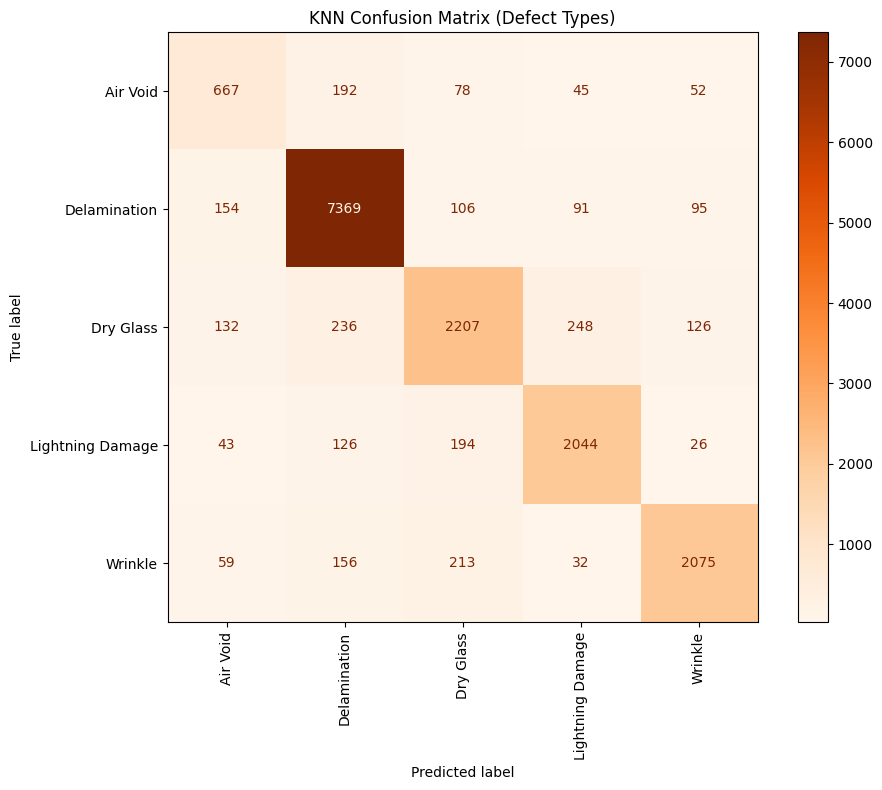

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay

# Izveido grafiku (Create the plot)
fig, ax = plt.subplots(figsize=(10, 8))

# Ģenerē Confusion Matrix KNN modelim
ConfusionMatrixDisplay.from_predictions(
    y_test, knn_pred,
    cmap='Oranges', 
    ax=ax, 
    xticks_rotation='vertical' # Pagriež tekstus, lai tie nepārklātos
)

ax.set_title('KNN Confusion Matrix (Defect Types)')
plt.tight_layout()
plt.show()

Labākais no modeļiem bija KNN un augšā ir tā Confusion Matrix vizualizācija. Delamination ir labākie rezultāti, jo šim defektu tipam bija visvairāk datu. Air Void nav tik labi rezultāti un visvairāk False Positives(FP) bija par Delaminations, jo tur ir visvairāk rindu un Air Void ir vismazāk. Dryglass FP(neskaitot Delaminations) ir Lightning Damage(248), tas nozīmē, ka starp abiem defektu tipiem ir vislielākā līdzība datos.   

GridSearchCV hiperparametru piemērošana Random Forest.

In [14]:
from sklearn.model_selection import GridSearchCV

# Parametru tīkls (The settings we want to test)
param_grid = {
    'randomforestclassifier__n_estimators': [50, 100, 150],
    'randomforestclassifier__max_depth': [10, 20, None]
}

# GridSearchCV automātiska meklēšana + cross-validation
# cv=3 means it will test each combination 3 times to be sure
grid = GridSearchCV(rf_pipe, param_grid, cv=3, scoring='f1_weighted', n_jobs=-1)

print("Sāk meklēt labākos parametrus... (Starting Grid Search, please wait...)")
grid.fit(X_train, y_train)

# Show the results
print(f"Labākie parametri (Best Settings): {grid.best_params_}")
print(f"Labākais CV F1 (Best Train F1): {grid.best_score_:.3f}")

# Final test on our 20% secret test data
best_rf_pred = grid.predict(X_test)
best_rf_f1 = f1_score(y_test, best_rf_pred, average='weighted')
print(f"Testa F1 ar labāko modeli (Final Test F1): {best_rf_f1:.3f}")

Sāk meklēt labākos parametrus... (Starting Grid Search, please wait...)
Labākie parametri (Best Settings): {'randomforestclassifier__max_depth': None, 'randomforestclassifier__n_estimators': 150}
Labākais CV F1 (Best Train F1): 0.898
Testa F1 ar labāko modeli (Final Test F1): 0.913


GridSearchCV hiperparametru piemērošana KNN.

In [15]:
# Parametru tīkls KNN modelim (Settings to test for KNN)
knn_param_grid = {
    'kneighborsclassifier__n_neighbors': [3, 5, 7, 9, 11],
    'kneighborsclassifier__weights': ['uniform', 'distance']
}

# GridSearchCV for KNN
knn_grid = GridSearchCV(knn_pipe, knn_param_grid, cv=3, scoring='f1_weighted', n_jobs=-1)

print("Sāk meklēt labākos KNN parametrus... (Starting KNN Grid Search...)")
knn_grid.fit(X_train, y_train)

# Show the results
print(f"Labākie KNN parametri: {knn_grid.best_params_}")

# Final test on our 20% secret test data
best_knn_pred = knn_grid.predict(X_test)
best_knn_f1 = f1_score(y_test, best_knn_pred, average='weighted')
print(f"Testa F1 ar labāko KNN modeli (Final Test F1): {best_knn_f1:.3f}")

Sāk meklēt labākos KNN parametrus... (Starting KNN Grid Search...)
Labākie KNN parametri: {'kneighborsclassifier__n_neighbors': 11, 'kneighborsclassifier__weights': 'distance'}
Testa F1 ar labāko KNN modeli (Final Test F1): 0.889


GridSearchCV hiperparametru piemērošana Decision Tree un Logistic Regression.

In [16]:
# 1. Tune Decision Tree
dt_param_grid = {
    'decisiontreeclassifier__max_depth': [10, 20, 30, None],
    'decisiontreeclassifier__min_samples_split': [2, 5, 10]
}
dt_grid = GridSearchCV(dt_pipe, dt_param_grid, cv=3, scoring='f1_weighted', n_jobs=-1)
print("Sāk meklēt DT parametrus... (Tuning Decision Tree...)")
dt_grid.fit(X_train, y_train)
best_dt_pred = dt_grid.predict(X_test)
print(f"Testa F1 ar labāko DT modeli: {f1_score(y_test, best_dt_pred, average='weighted'):.3f}")

# 2. Tune Logistic Regression
lr_param_grid = {
    'logisticregression__C': [0.1, 1, 10],
    'logisticregression__max_iter': [2000] # Increased to prevent errors
}
lr_grid = GridSearchCV(lr_pipe, lr_param_grid, cv=3, scoring='f1_weighted', n_jobs=-1)
print("\nSāk meklēt LR parametrus... (Tuning Logistic Regression...)")
lr_grid.fit(X_train, y_train)
best_lr_pred = lr_grid.predict(X_test)
print(f"Testa F1 ar labāko LR modeli: {f1_score(y_test, best_lr_pred, average='weighted'):.3f}")

Sāk meklēt DT parametrus... (Tuning Decision Tree...)
Testa F1 ar labāko DT modeli: 0.891

Sāk meklēt LR parametrus... (Tuning Logistic Regression...)
Testa F1 ar labāko LR modeli: 0.771


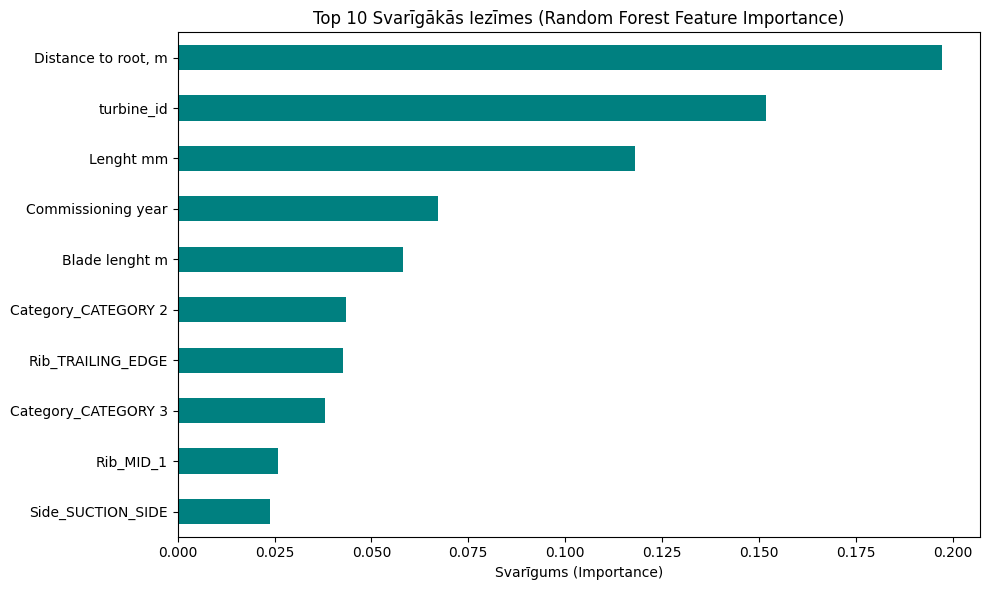

In [17]:
# Get the best Random Forest model from our GridSearchCV
best_rf = grid.best_estimator_.named_steps['randomforestclassifier']

# Get the importance scores and the column names
importances = best_rf.feature_importances_
feature_names = X.columns

# Create a Pandas Series and sort them
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# Plot the Top 10 most important features
plt.figure(figsize=(10, 6))
feat_imp.head(10).plot(kind='barh', color='teal')
plt.title('Top 10 Svarīgākās Iezīmes (Random Forest Feature Importance)')
plt.xlabel('Svarīgums (Importance)')
plt.gca().invert_yaxis() # Puts the most important at the top
plt.tight_layout()
plt.show()

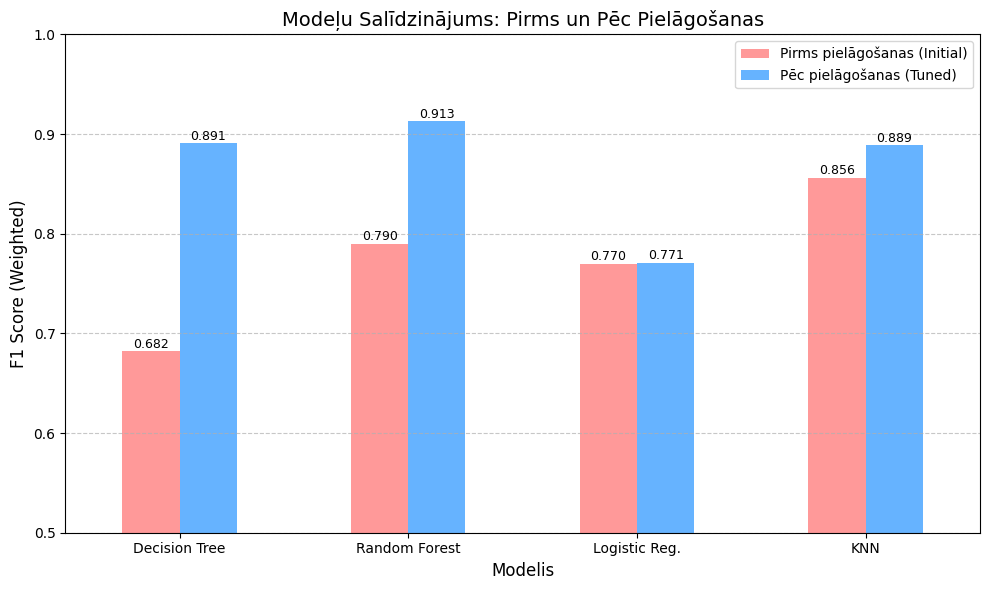

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Dati par modeļu rezultātiem (Data of the model results)
# [Decision Tree, Random Forest, Logistic Regression, KNN]
initial_scores = [0.682, 0.790, 0.770, 0.856]
tuned_scores = [0.891, 0.913, 0.771, 0.889]
models = ['Decision Tree', 'Random Forest', 'Logistic Reg.', 'KNN']

# Izveidojam DataFrame (Create a DataFrame for easy plotting)
comparison_df = pd.DataFrame({
    'Pirms pielāgošanas (Initial)': initial_scores,
    'Pēc pielāgošanas (Tuned)': tuned_scores
}, index=models)

# Zīmējam grafiku (Draw the plot)
ax = comparison_df.plot(kind='bar', figsize=(10, 6), color=['#ff9999', '#66b3ff'])

# Formatējums (Formatting)
plt.title('Modeļu Salīdzinājums: Pirms un Pēc Pielāgošanas', fontsize=14)
plt.ylabel('F1 Score (Weighted)', fontsize=12)
plt.xlabel('Modelis', fontsize=12)
plt.xticks(rotation=0) # Keeps model names horizontal
plt.ylim(0.5, 1.0) # Set Y-axis to start at 0.5 to better see the differences
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Pievienojam vērtības uz stabiņiem (Add numbers on top of the bars)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 5), textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.show()

In [19]:
from sklearn.metrics import classification_report

print("=== 1. RANDOM FOREST (Uzvarētājs / Winner) ===")
print(classification_report(y_test, best_rf_pred))

print("\n=== 2. DECISION TREE ===")
print(classification_report(y_test, best_dt_pred))

print("\n=== 3. KNN ===")
print(classification_report(y_test, best_knn_pred))

print("\n=== 4. LOGISTIC REGRESSION ===")
print(classification_report(y_test, best_lr_pred))

=== 1. RANDOM FOREST (Uzvarētājs / Winner) ===
                  precision    recall  f1-score   support

        Air Void       0.79      0.75      0.77      1034
    Delamination       0.96      0.97      0.96      7815
       Dry Glass       0.86      0.84      0.85      2949
Lightning Damage       0.89      0.92      0.90      2433
         Wrinkle       0.91      0.90      0.90      2535

        accuracy                           0.91     16766
       macro avg       0.88      0.87      0.88     16766
    weighted avg       0.91      0.91      0.91     16766


=== 2. DECISION TREE ===
                  precision    recall  f1-score   support

        Air Void       0.72      0.71      0.71      1034
    Delamination       0.96      0.96      0.96      7815
       Dry Glass       0.81      0.81      0.81      2949
Lightning Damage       0.87      0.87      0.87      2433
         Wrinkle       0.87      0.88      0.88      2535

        accuracy                           0.89     

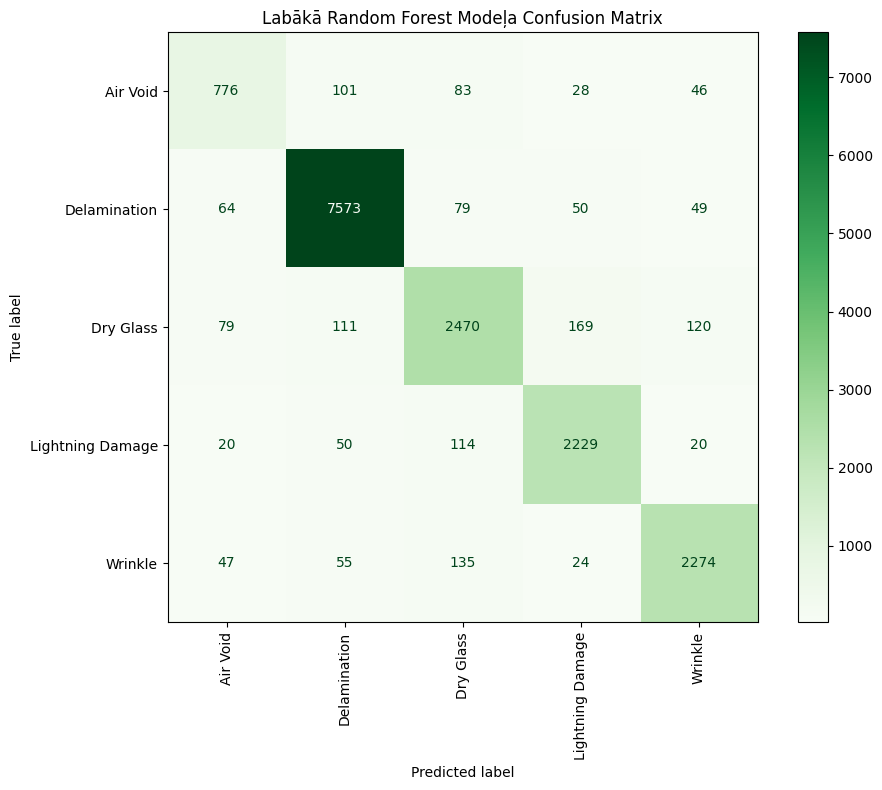

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Izveido grafiku (Create the plot)
fig, ax = plt.subplots(figsize=(10, 8))

# Ģenerē Confusion Matrix labākajam Random Forest modelim
ConfusionMatrixDisplay.from_predictions(
    y_test, best_rf_pred,
    cmap='Greens', 
    ax=ax, 
    xticks_rotation='vertical' # Pagriež tekstus, lai tie nepārklātos
)

ax.set_title('Labākā Random Forest Modeļa Confusion Matrix')
plt.tight_layout()
plt.show()

1. Modeļu Rezultāti (Model Results)

Projektā tika apmācīti un salīdzināti 4 klasifikācijas modeļi: Decision Tree, Random Forest, Logistic Regression un KNN.

Uzvarētājs ir Random Forest modelis, kas pēc hiperparametru pielāgošanas (GridSearchCV) sasniedza izcilu 91.3% F1 rezultātu.

Modelis vislabāk spēj atpazīt "Delamination" defektus, jo tie datos bija visbiežāk sastopami. Tādēļ Air Void bija sliktāki resultāti, jo modeļiem bija maz datu, no kuriem mācīties un atrast sakarības. tas saucās Class Imbalance.

2. Svarīgākās Iezīmes (Most Important Features)

Saskaņā ar Random Forest Feature Importance analīzi, galvenie faktori, kas nosaka defekta tipu, ir:

Distance to root, m (Defekta attālums no pamatnes)

Turbine_id / Turbine model (Konkrētais turbīnas modelis)

Lenght mm (Defekta garums)

3. Biznesa Ieguvumi (Business Logic & Impact)
Kāpēc šis modelis ir noderīgs uzņēmumam?

Ātrāka defektu klasifikācija: Sistēma var automātiski prognozēt defekta veidu, balstoties uz pamata mērījumiem (attālums, garums, turbīnas modelis), ietaupot inženieru laiku manuālai datu analīzei.

Paredzamā apkope (Predictive Maintenance): Zinot, ka konkrēti turbīnu modeļi ir ļoti svarīgs faktors defektu rašanās procesā, uzņēmums var proaktīvi plānot inspekcijas tieši tiem modeļiem, kuriem ir augsts risks iegūt nopietnus bojājumus (piemēram, Delamination).

Izmaksu samazināšana: Precīza un ātra defektu atpazīšana ļauj laicīgi sagatavot pareizos labošanas materiālus pirms inženieru komanda dodas uz objektu.